# Load Libraries

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels as sm
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet,HuberRegressor, QuantileRegressor, TheilSenRegressor,SGDRegressor, Lars, GammaRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor, AdaBoostRegressor, ExtraTreesRegressor, StackingRegressor, BaggingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer, PolynomialFeatures, LabelEncoder, OneHotEncoder, OrdinalEncoder, LabelBinarizer, KBinsDiscretizer
from sklearn.decomposition import PCA, TruncatedSVD, FastICA, KernelPCA, NMF
from sklearn.feature_selection import SelectKBest, SelectFromModel, RFE, RFECV, SequentialFeatureSelector, VarianceThreshold, GenericUnivariateSelect, SelectPercentile, SelectFpr, SelectFdr, SelectFwe, GenericUnivariateSelect, SelectPercentile, SelectFpr, SelectFdr, SelectFwe
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.utils import resample
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

Load Data

In [94]:
df = pd.read_csv("diamonds.csv")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# EDA Analysis

## Stats

In [95]:
# Dataset Statistics
print("\n📈 Dataset Statistics:")
print(df.describe())

# Check for missing values
print(f"\n🔍 Missing Values: {df.isnull().sum().sum()}")


📈 Dataset Statistics:
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.200000     43.000000     43.000000    326.000000      0.000000   
25%        0.400000     61.000000     56.000000    950.000000      4.710000   
50%        0.700000     61.800000     57.000000   2401.000000      5.700000   
75%        1.040000     62.500000     59.000000   5324.250000      6.540000   
max        5.010000     79.000000     95.000000  18823.000000     10.740000   

                  y             z  
count  53940.000000  53940.000000  
mean       5.734526      3.538734  
std        1.142135      0.705699  
min        0.000000      0.000000  
25%        4.720000      2.910000  
50%        5.710000      3.530000  
75%        6.

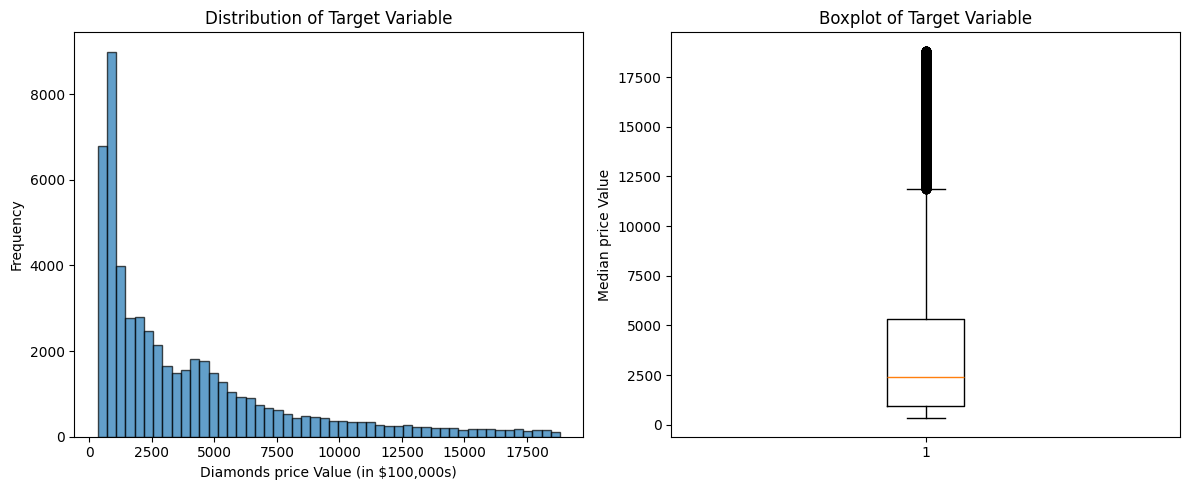

In [96]:
# Visualize Target Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Diamonds price Value (in $100,000s)')
plt.ylabel('Frequency')
plt.title('Distribution of Target Variable')

plt.subplot(1, 2, 2)
plt.boxplot(df['price'])
plt.ylabel('Median price Value')
plt.title('Boxplot of Target Variable')

plt.tight_layout()
plt.show()

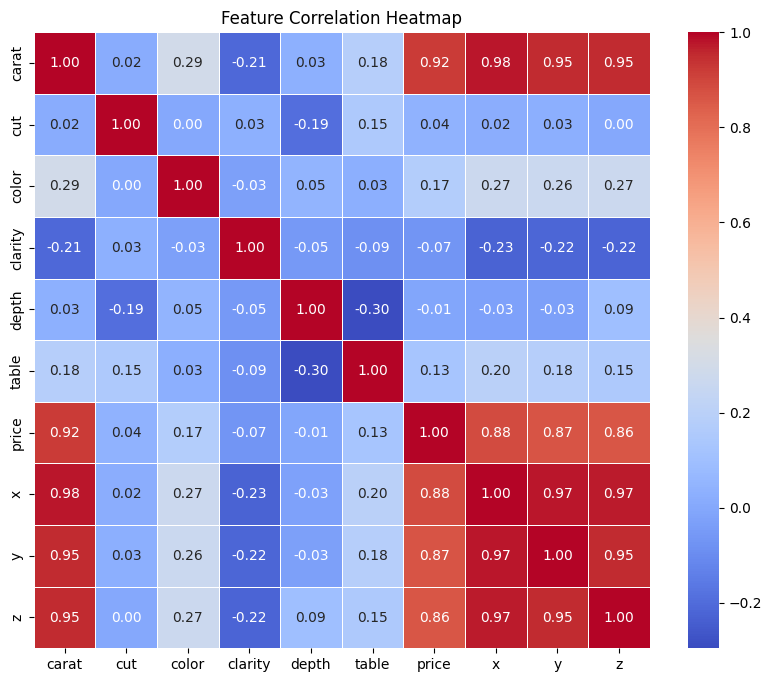


🔗 Features Correlation with Target (price):
price      1.000000
carat      0.921591
x          0.884435
y          0.865421
z          0.861249
color      0.172511
table      0.127134
cut        0.039860
depth     -0.010647
clarity   -0.071535
Name: price, dtype: float64


In [97]:
df_encoded = df.copy()
for col in df_encoded.select_dtypes(include='object'):
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

correlation_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()
# Identify features most correlated with target
target_corr = correlation_matrix['price'].sort_values(ascending=False)
print("\n🔗 Features Correlation with Target (price):")
print(target_corr)

In [98]:
# Agar koi unordered column hota (e.g., 'city')
df = pd.get_dummies(df, columns=['color','cut','clarity'], drop_first=True)

In [99]:
# Split Features and Target
X = df.drop('price', axis=1)
y = df['price']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n✂️ Data Split:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Feature count: {X_train.shape[1]}")


✂️ Data Split:
Training set: 43152 samples
Testing set: 10788 samples
Feature count: 23


In [100]:
# Simple Linear Regression with Single Feature
X_train_simple = X_train[['carat']]
X_test_simple = X_test[['carat']]

# Initialize and train model
simple_lr = LinearRegression()
simple_lr.fit(X_train_simple, y_train)

# Make predictions
y_pred_simple = simple_lr.predict(X_test_simple)

print("🎯 Simple Linear Regression Model Trained")
print(f"Intercept (β₀): {simple_lr.intercept_:.4f}")
print(f"Coefficient (β₁): {simple_lr.coef_[0]:.4f}")
print(f"\nEquation: ŷ = {simple_lr.intercept_:.4f} + {simple_lr.coef_[0]:.4f} × carat")

🎯 Simple Linear Regression Model Trained
Intercept (β₀): -2261.9117
Coefficient (β₁): 7768.9105

Equation: ŷ = -2261.9117 + 7768.9105 × carat


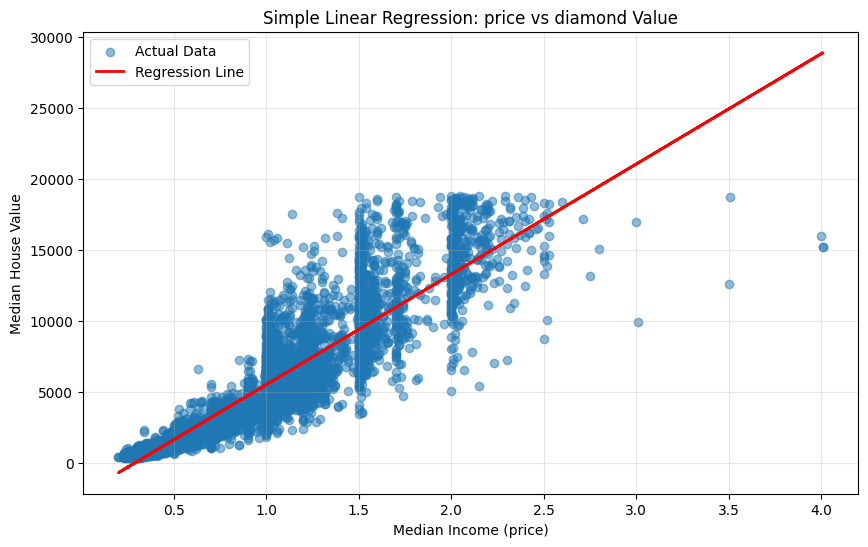

In [101]:
# Visualize Simple Linear Regression
plt.figure(figsize=(10, 6))
plt.scatter(X_test_simple, y_test, alpha=0.5, label='Actual Data')
plt.plot(X_test_simple, y_pred_simple, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Median Income (price)')
plt.ylabel('Median House Value')
plt.title('Simple Linear Regression: price vs diamond Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [102]:
# Multiple Linear Regression with All Features
multiple_lr = LinearRegression()
multiple_lr.fit(X_train, y_train)

# Make predictions
y_pred_multiple = multiple_lr.predict(X_test)

print("🎯 Multiple Linear Regression Model Trained")
print(f"Intercept (β₀): {multiple_lr.intercept_:.4f}")
print("\n📊 Feature Coefficients (β):")

# Display coefficients in a clean format
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': multiple_lr.coef_
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))

🎯 Multiple Linear Regression Model Trained
Intercept (β₀): 2263.8269

📊 Feature Coefficients (β):
      Feature  Coefficient
        carat 11280.784327
   clarity_IF  5365.944596
 clarity_VVS1  5015.292916
 clarity_VVS2  4958.211449
  clarity_VS1  4579.905541
  clarity_VS2  4263.615635
  clarity_SI1  3675.414552
  clarity_SI2  2701.439970
    cut_Ideal   858.815946
  cut_Premium   781.928178
cut_Very Good   749.952180
     cut_Good   591.797169
            y    -3.528450
        table   -26.600021
            z   -36.463370
        depth   -65.091015
      color_E  -218.198603
      color_F  -279.716403
      color_G  -495.581527
      color_H  -999.086408
            x -1008.041596
      color_I -1479.584470
      color_J -2372.019835


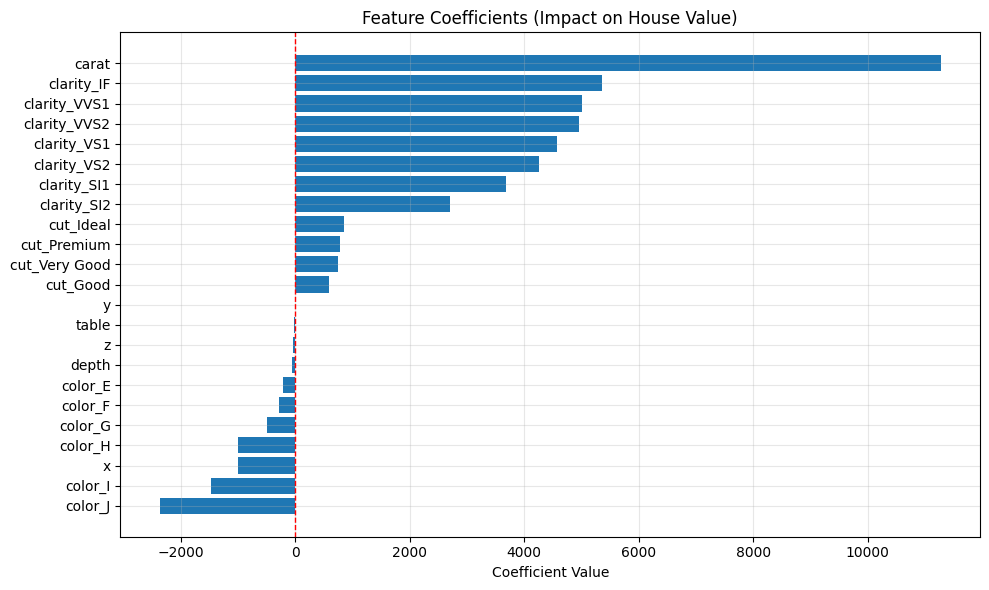

In [103]:
# Visualize Feature Importance (Coefficient Magnitude)
plt.figure(figsize=(10, 6))
coef_df_sorted = coef_df.sort_values('Coefficient')
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'])
plt.xlabel('Coefficient Value')
plt.title('Feature Coefficients (Impact on House Value)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [104]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model on scaled data
scaled_lr = LinearRegression()
scaled_lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_scaled = scaled_lr.predict(X_test_scaled)

print("🎯 Standardized Linear Regression Model Trained")
print(f"Intercept: {scaled_lr.intercept_:.4f}")
print("\n📊 Standardized Coefficients:")

scaled_coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Std_Coefficient': scaled_lr.coef_
}).sort_values('Std_Coefficient', key=abs, ascending=False)

print(scaled_coef_df.to_string(index=False))

🎯 Standardized Linear Regression Model Trained
Intercept: 3939.4907

📊 Standardized Coefficients:
      Feature  Std_Coefficient
        carat      5339.601689
  clarity_VS2      1785.835722
  clarity_VS1      1641.282019
  clarity_SI1      1578.102172
 clarity_VVS2      1444.982181
 clarity_VVS1      1264.504887
            x     -1129.191378
  clarity_SI2      1013.105275
   clarity_IF       960.496603
      color_J      -525.774927
      color_I      -441.985530
    cut_Ideal       420.724856
      color_H      -361.980564
  cut_Premium       340.936743
cut_Very Good       313.061422
      color_G      -201.469692
     cut_Good       169.720936
      color_F      -106.792426
        depth       -92.964717
      color_E       -84.229622
        table       -59.299400
            z       -25.818033
            y        -4.048849


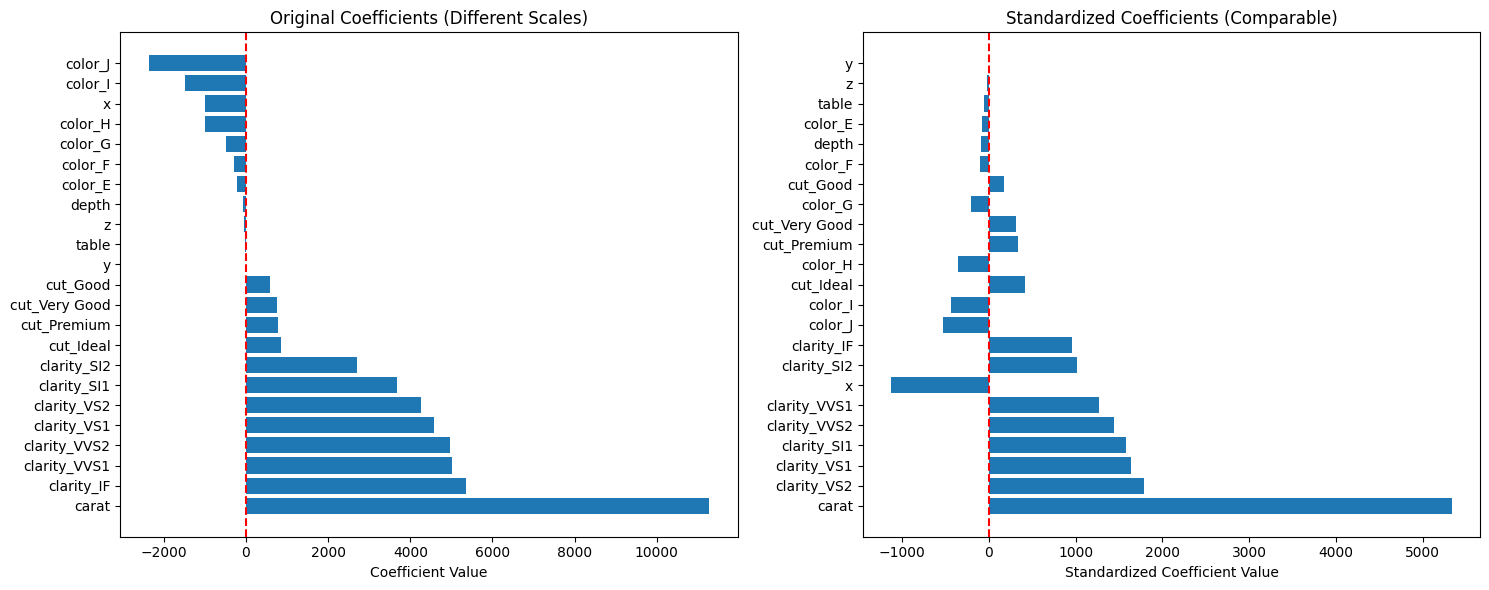

In [105]:
# Compare coefficient magnitudes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Original coefficients
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'])
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title('Original Coefficients (Different Scales)')
axes[0].axvline(x=0, color='red', linestyle='--')

# Standardized coefficients
axes[1].barh(scaled_coef_df['Feature'], scaled_coef_df['Std_Coefficient'])
axes[1].set_xlabel('Standardized Coefficient Value')
axes[1].set_title('Standardized Coefficients (Comparable)')
axes[1].axvline(x=0, color='red', linestyle='--')

plt.tight_layout()
plt.show()

In [107]:
print(X_train.columns)
# Is output mein 'cut', 'color', aur 'clarity' ka hona lazmi hai.

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'color_E', 'color_F',
       'color_G', 'color_H', 'color_I', 'color_J', 'cut_Good', 'cut_Ideal',
       'cut_Premium', 'cut_Very Good', 'clarity_IF', 'clarity_SI1',
       'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1',
       'clarity_VVS2'],
      dtype='object')


In [108]:
# 1. Pipeline define karein (Ab preprocessor ki zaroorat nahi kyunki data already encoded hai)
# Hum sirf StandardScaler use karenge taake coefficients sahi nikal skein
master_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('regressor', XGBRegressor()) # Placeholder
])

# 2. Complete Model List with Best Hyperparameters for Metrics
param_grid = [
    # XGBoost: Sabse behtreen balance
    {
        'regressor': [XGBRegressor(random_state=42, objective='reg:squarederror')],
        'regressor__n_estimators': [500, 1000],
        'regressor__learning_rate': [0.05, 0.1],
        'regressor__max_depth': [3, 5, 7],
        'regressor__colsample_bytree': [0.8, 1.0]
    },
    # LightGBM: Accuracy + Speed
    {
        'regressor': [LGBMRegressor(random_state=42, verbose=-1)],
        'regressor__n_estimators': [500, 1000],
        'regressor__learning_rate': [0.05, 0.1],
        'regressor__num_leaves': [31, 64],
        'regressor__feature_fraction': [0.8, 0.9]
    },
    # CatBoost: Categorical patterns pakadne mein mahir
    {
        'regressor': [CatBoostRegressor(random_state=42, silent=True)],
        'regressor__iterations': [500, 1000],
        'regressor__learning_rate': [0.03, 0.1],
        'regressor__depth': [4, 6, 8]
    },
    # Bonus: Random Forest (Baseline ke liye)
    {
        'regressor': [RandomForestRegressor(random_state=42)],
        'regressor__n_estimators': [200, 500],
        'regressor__max_features': ['sqrt', 'log2']
    }
]

# 3. Fit the Model (Using 5-Fold Cross Validation)
grid_search = GridSearchCV(
    master_pipeline, 
    param_grid, 
    cv=5, 
    scoring='r2', # Accuracy ke liye R2 score best hai
    n_jobs=-1, 
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 56 candidates, totalling 280 fits
[CV] END regressor=XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...), regressor__colsample_bytree=0.8, regressor__learning_rate=0.05, regressor__max_depth=3, regressor__n_estimators=500; total time=   3.5s
[CV] END regressor=XGBRegressor(

/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 4.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 5.2min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 5.8min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.7min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 7.1min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.5min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=11.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time= 8.8min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time=10.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time=12.5min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time= 9.8min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time=12.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 4.8min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.5min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 5.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.2min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=19.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.7min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=19.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=19.3min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=21.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time= 9.2min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=22.8min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time= 8.7min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.7min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.2min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time= 9.8min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time=12.1min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time=10.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time=11.5min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time=12.7min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time=12.3min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.1min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 7.6min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.7min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=19.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 5.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=18.6min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=19.2min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=31; total time= 7.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=18.7min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.8, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=21.1min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=12.8min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.7min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.6min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.1min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time=11.3min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time=12.6min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time=12.2min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time=11.4min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=31; total time=11.3min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.2min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.5min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=19.2min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 7.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=21.8min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=31; total time= 6.4min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=20.8min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=22.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.05, regressor__n_estimators=1000, regressor__num_leaves=64; total time=20.2min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.1min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time= 9.6min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time= 8.0min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.4min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=500, regressor__num_leaves=64; total time=10.9min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time=10.3min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time=11.4min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time= 9.0min
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7cf4f0>, regressor__depth=4, regressor__iterations=500, regressor__learning_rate=0.03; total time=  11.1s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7cf220>, regressor__depth=4, regressor__iterations=500, regressor__learning_rate=0.03; total time=  11.0s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7cff10>, regressor__depth=4, regressor__iterations=500, regressor__learning_rate=0.03; total time=  10.3s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7cee60>, regressor__depth=4, regressor__iterations=500, regressor__learning_rate=0.03; total time=  10.6s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7cf970>, regressor__depth

/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7cf400>, regressor__depth=4, regressor__iterations=500, regressor__learning_rate=0.1; total time=  11.5s
[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time=12.0min
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7cff10>, regressor__depth=4, regressor__iterations=500, regressor__learning_rate=0.1; total time=  12.1s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x7b7564717e20>, regressor__depth=4, regressor__iterations=500, regressor__learning_rate=0.1; total time=  13.2s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7cff10>, regressor__depth=4, regressor__iterations=1000, regressor__learning_rate=0.03; total time=  20.5s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x7b75647873a0>, regressor__depth=4

/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=31; total time=13.1min
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7cfdf0>, regressor__depth=4, regressor__iterations=1000, regressor__learning_rate=0.1; total time=  22.9s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x7b7564787a00>, regressor__depth=4, regressor__iterations=1000, regressor__learning_rate=0.1; total time=  22.5s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x7ad5dc317ca0>, regressor__depth=4, regressor__iterations=1000, regressor__learning_rate=0.1; total time=  26.5s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x7b75647858a0>, regressor__depth=6, regressor__iterations=500, regressor__learning_rate=0.03; total time=  17.1s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f7c28f0>, regressor__depth

/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=17.4min
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x72b72f0c7e80>, regressor__depth=8, regressor__iterations=1000, regressor__learning_rate=0.1; total time=  59.5s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x7ad5dc316f80>, regressor__depth=8, regressor__iterations=1000, regressor__learning_rate=0.1; total time=  56.9s
[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x7b75647879d0>, regressor__depth=8, regressor__iterations=1000, regressor__learning_rate=0.1; total time=  57.4s


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=<catboost.core.CatBoostRegressor object at 0x77456c9c24a0>, regressor__depth=8, regressor__iterations=1000, regressor__learning_rate=0.1; total time=  54.2s
[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=17.4min
[CV] END regressor=RandomForestRegressor(random_state=42), regressor__max_features=sqrt, regressor__n_estimators=200; total time=  40.8s


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=14.8min
[CV] END regressor=RandomForestRegressor(random_state=42), regressor__max_features=sqrt, regressor__n_estimators=200; total time=  38.2s


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=RandomForestRegressor(random_state=42), regressor__max_features=sqrt, regressor__n_estimators=200; total time=  46.2s
[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=16.4min


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[CV] END regressor=LGBMRegressor(random_state=42, verbose=-1), regressor__feature_fraction=0.9, regressor__learning_rate=0.1, regressor__n_estimators=1000, regressor__num_leaves=64; total time=11.9min
[CV] END regressor=RandomForestRegressor(random_state=42), regressor__max_features=sqrt, regressor__n_estimators=200; total time=  34.2s
[CV] END regressor=RandomForestRegressor(random_state=42), regressor__max_features=sqrt, regressor__n_estimators=200; total time=  35.1s
[CV] END regressor=RandomForestRegressor(random_state=42), regressor__max_features=log2, regressor__n_estimators=200; total time=  36.1s
[CV] END regressor=RandomForestRegressor(random_state=42), regressor__max_features=log2, regressor__n_estimators=200; total time=  39.9s
[CV] END regressor=RandomForestRegressor(random_state=42), regressor__max_features=log2, regressor__n_estimators=200; total time=  39.0s
[CV] END regressor=RandomForestRegressor(random_state=42), regressor__max_features=log2, regressor__n_estimators=2

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"[{'regressor': [XGBRegressor(...ree=None, ...)], 'regressor__colsample_bytree': [0.8, 1.0], 'regressor__learning_rate': [0.05, 0.1], 'regressor__max_depth': [3, 5, ...], ...}, {'regressor': [LGBMRegressor...2, verbose=-1)], 'regressor__feature_fraction': [0.8, 0.9], 'regressor__learning_rate': [0.05, 0.1], 'regressor__n_estimators': [500, 1000], ...}, ...]"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [109]:
# Predictions
y_pred = grid_search.predict(X_test)

# Best Model Metrics
print(f"🔥 Winner Model: {grid_search.best_params_['regressor']}")
print(f"✅ R2 Score (Accuracy): {r2_score(y_test, y_pred):.4f}")
print(f"📉 MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"📏 RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

🔥 Winner Model: LGBMRegressor(random_state=42, verbose=-1)
✅ R2 Score (Accuracy): 0.9812
📉 MAE: 280.37
📏 RMSE: 547.07


/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [111]:
# Metrics calculate karne ka function taake code repeat na ho
def get_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

# Maan letay hain ke aapke paas y_pred_simple, y_pred_multiple wagaira maujood hain
simple_metrics = get_metrics(y_test, y_pred_simple)
multiple_metrics = get_metrics(y_test, y_pred_multiple)
scaled_metrics = get_metrics(y_test, y_pred_scaled)

In [112]:
comparison_df = pd.DataFrame({
    'Simple LR': simple_metrics,
    'Multiple LR': multiple_metrics,
    'Scaled LR': scaled_metrics
})

print("\n📊 Model Comparison Summary:")
print(comparison_df.round(4)) # Rounding for clean look


📊 Model Comparison Summary:
      Simple LR  Multiple LR  Scaled LR
MAE   1009.5047     737.1514   737.1514
RMSE  1549.6415    1135.2116  1135.2116
R2       0.8489       0.9189     0.9189


DataFrame Index: ['MAE', 'RMSE', 'R2']


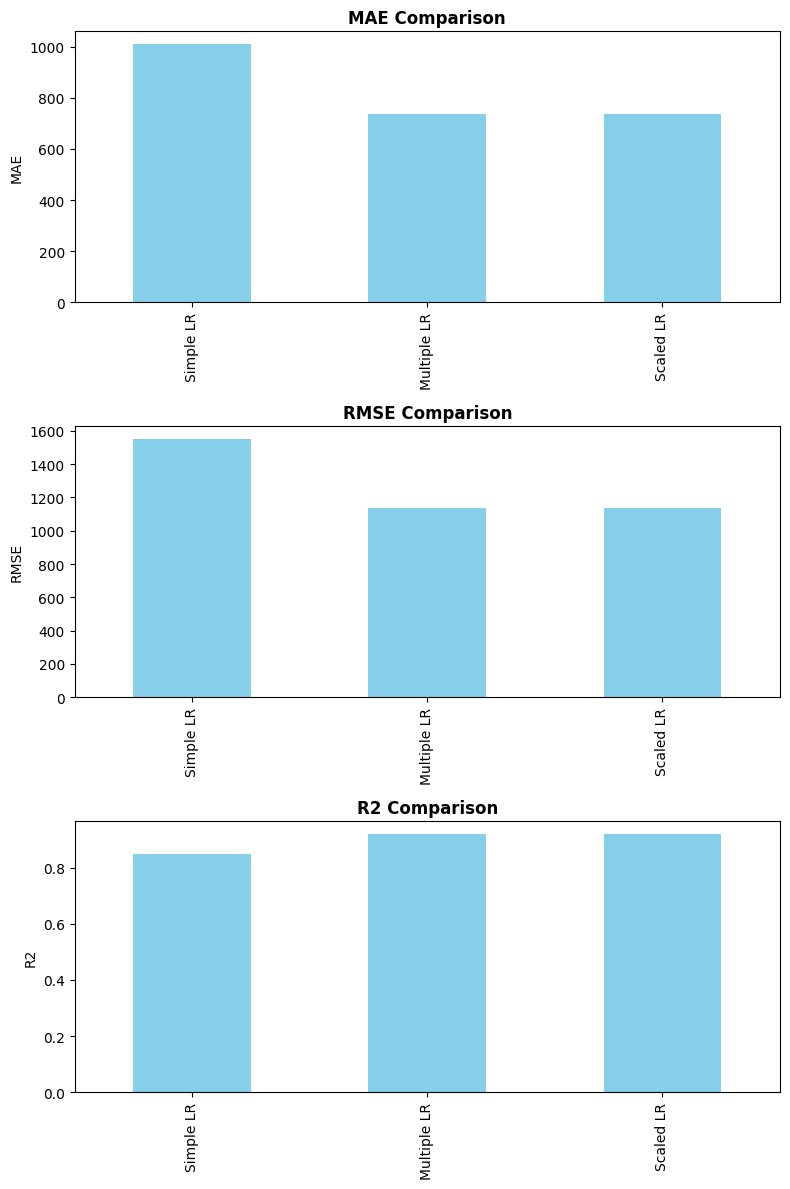

In [114]:
# 1. Pehle check karein ke DataFrame mein kaunse metrics hain
print("DataFrame Index:", comparison_df.index.tolist())

# 2. Sirf wahi metrics loop mein use karein jo DataFrame mein maujood hain
metrics_in_df = comparison_df.index.tolist()

fig, axes = plt.subplots(len(metrics_in_df), 1, figsize=(8, 12)) # Dynamic subplot creation

for idx, metric in enumerate(metrics_in_df):
    # Agar axes 1D hai toh sirf axes[idx] use karein
    comparison_df.loc[metric].plot(kind='bar', ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(metric)

plt.tight_layout()
plt.show()

In [115]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Predictions generate karein
y_pred = grid_search.predict(X_test)

# Metrics store karein (Keys ka dhyan rakhein)
final_metrics = {
    'MAE': mean_absolute_error(y_test, y_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
    'R2': r2_score(y_test, y_pred)
}

# comparison_df mein add karein
comparison_df['Best_Model'] = pd.Series(final_metrics)

/home/datalab/anaconda3/envs/Lab/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


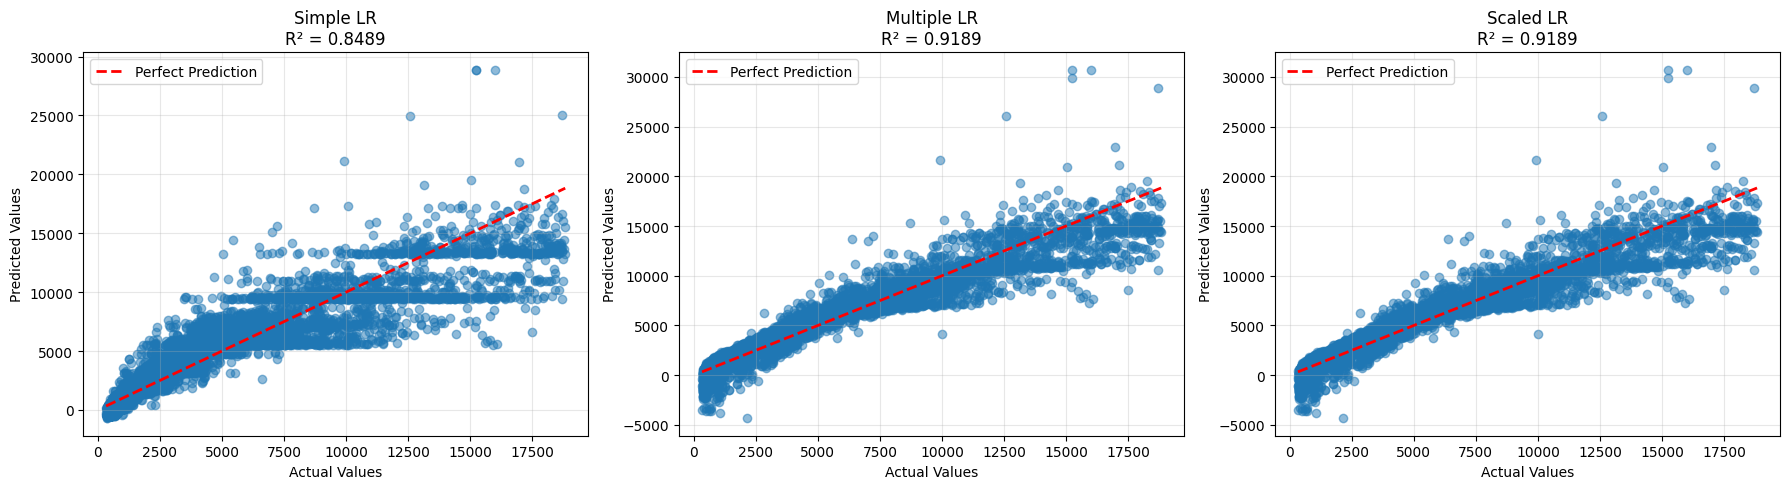

In [116]:
# Scatter plot: Predictions vs Actual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ('Simple LR', y_pred_simple),
    ('Multiple LR', y_pred_multiple),
    ('Scaled LR', y_pred_scaled)
]

for idx, (name, predictions) in enumerate(models):
    axes[idx].scatter(y_test, predictions, alpha=0.5)
    axes[idx].plot([y_test.min(), y_test.max()], 
                   [y_test.min(), y_test.max()], 
                   'r--', lw=2, label='Perfect Prediction')
    axes[idx].set_xlabel('Actual Values')
    axes[idx].set_ylabel('Predicted Values')
    axes[idx].set_title(f'{name}\nR² = {r2_score(y_test, predictions):.4f}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

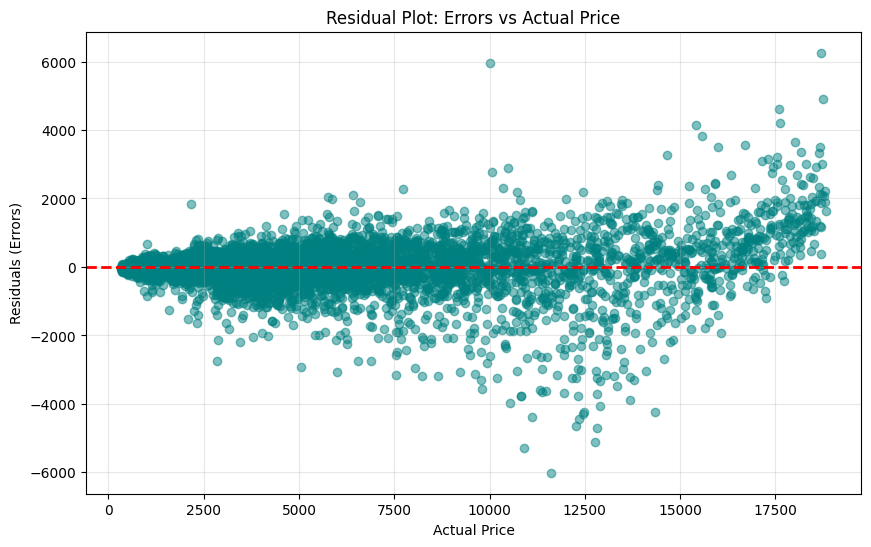

In [119]:
# 1. Residuals calculate karein
residuals = y_test - y_pred

# 2. Plotting (Corrected Line)
plt.figure(figsize=(10, 6))

# Error yahan tha: X_test['price'] nahi mil raha tha. 
# Hum Actual y_test ya Predicted y_pred use karte hain x-axis par.
plt.scatter(y_test, residuals, alpha=0.5, color='teal') 

plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Actual Price')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot: Errors vs Actual Price')
plt.grid(True, alpha=0.3)
plt.show()

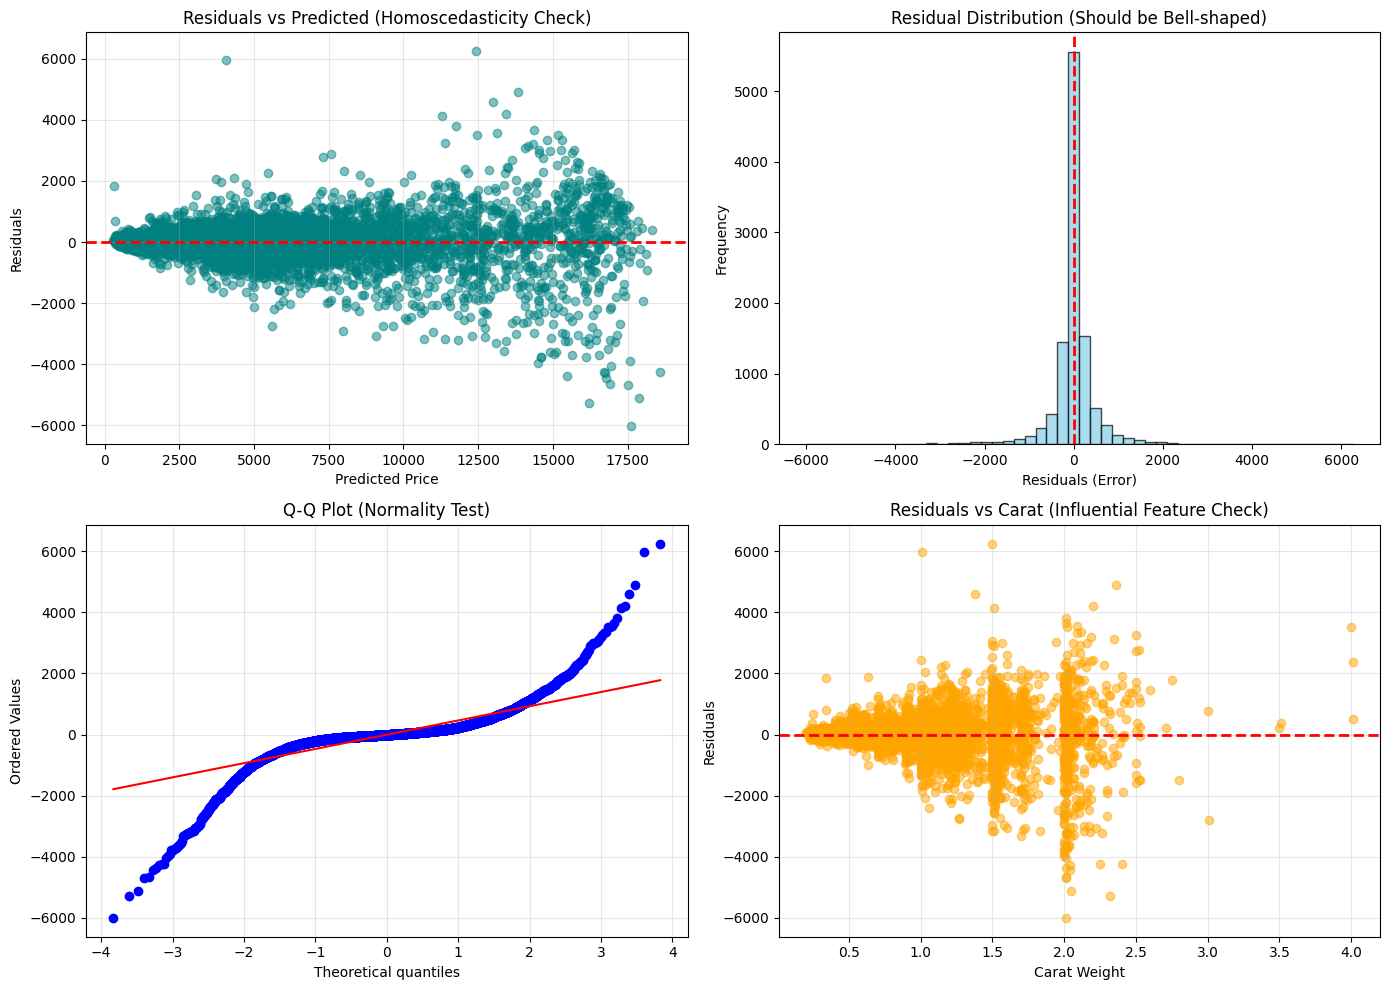


📊 Residual Statistics:
Mean: -4.826789 (Zero ke qareeb hona chahiye)
Std Dev: 547.0713
Skewness: -0.7758


In [120]:
# 1. Residuals Calculate karein (Yahan 'y_pred' use karein jo aapne GridSearchCV se nikala tha)
# Agar aapka variable name alag hai toh usey yahan update karein
residuals = y_test - y_pred  

# Residual plots setup
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. Residuals vs Predicted Values ---
axes[0, 0].scatter(y_pred, residuals, alpha=0.5, color='teal')
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted Price')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted (Homoscedasticity Check)')
axes[0, 0].grid(True, alpha=0.3)

# --- 2. Histogram of Residuals ---
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Residuals (Error)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Residual Distribution (Should be Bell-shaped)')

# --- 3. Q-Q Plot ---
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normality Test)')
axes[1, 0].grid(True, alpha=0.3)

# --- 4. Residuals vs Feature ('carat') ---
# 'MedInc' ko 'carat' se replace kiya kyunki Diamond data mein yahi main feature hai
axes[1, 1].scatter(X_test['carat'], residuals, alpha=0.5, color='orange')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Carat Weight') # Label updated
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs Carat (Influential Feature Check)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual Statistics
print(f"\n📊 Residual Statistics:")
print(f"Mean: {residuals.mean():.6f} (Zero ke qareeb hona chahiye)")
print(f"Std Dev: {residuals.std():.4f}")
print(f"Skewness: {stats.skew(residuals):.4f}")


🔄 5-Fold Cross-Validation Results:
R² Scores: [0.92208156 0.91744922 0.91462823 0.92276713 0.92186453]
Mean R²: 0.9198
Std Dev: 0.0032


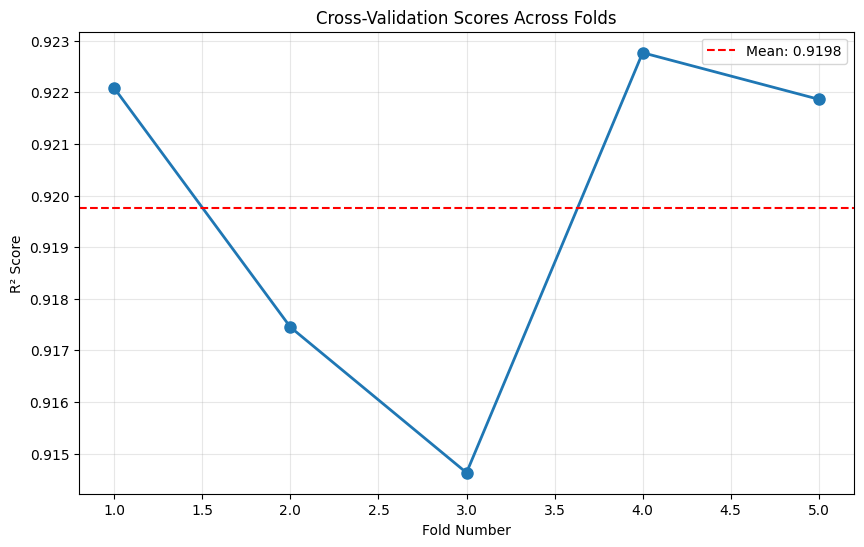

In [121]:
# Perform 5-Fold Cross-Validation
cv_scores = cross_val_score(
    LinearRegression(), 
    X_train_scaled, 
    y_train, 
    cv=5, 
    scoring='r2'
)

print("\n🔄 5-Fold Cross-Validation Results:")
print(f"R² Scores: {cv_scores}")
print(f"Mean R²: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

# Visualize CV scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold Number')
plt.ylabel('R² Score')
plt.title('Cross-Validation Scores Across Folds')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


🔍 Feature Importance Ranking:
      Feature  Importance  Coefficient
        carat 5339.601689  5339.601689
  clarity_VS2 1785.835722  1785.835722
  clarity_VS1 1641.282019  1641.282019
  clarity_SI1 1578.102172  1578.102172
 clarity_VVS2 1444.982181  1444.982181
 clarity_VVS1 1264.504887  1264.504887
            x 1129.191378 -1129.191378
  clarity_SI2 1013.105275  1013.105275
   clarity_IF  960.496603   960.496603
      color_J  525.774927  -525.774927
      color_I  441.985530  -441.985530
    cut_Ideal  420.724856   420.724856
      color_H  361.980564  -361.980564
  cut_Premium  340.936743   340.936743
cut_Very Good  313.061422   313.061422
      color_G  201.469692  -201.469692
     cut_Good  169.720936   169.720936
      color_F  106.792426  -106.792426
        depth   92.964717   -92.964717
      color_E   84.229622   -84.229622
        table   59.299400   -59.299400
            z   25.818033   -25.818033
            y    4.048849    -4.048849


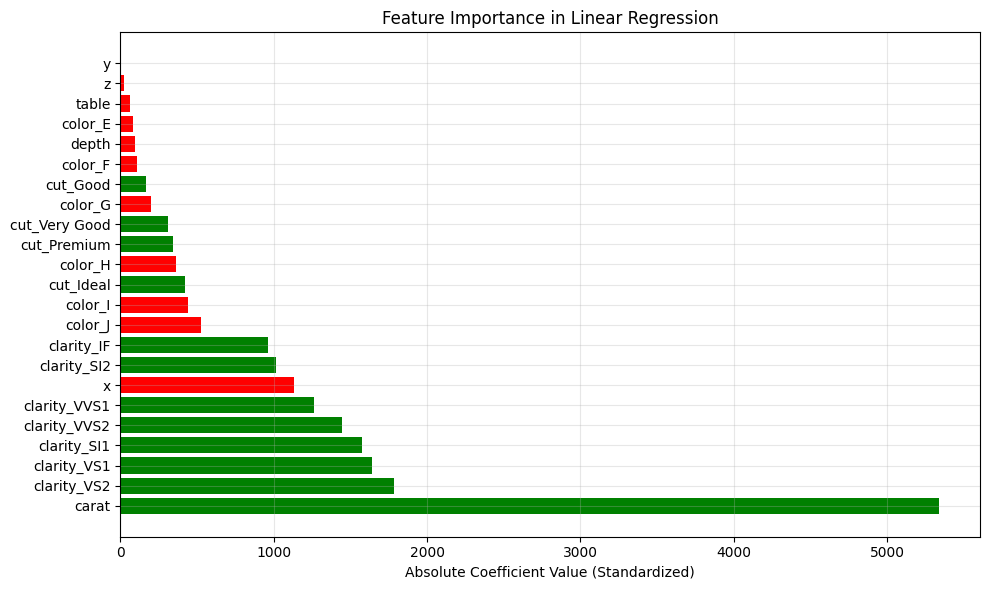

In [122]:
# Feature importance based on standardized coefficients
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': np.abs(scaled_lr.coef_),
    'Coefficient': scaled_lr.coef_
}).sort_values('Importance', ascending=False)

print("\n🔍 Feature Importance Ranking:")
print(feature_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], 
         color=['green' if x > 0 else 'red' for x in feature_importance['Coefficient']])
plt.xlabel('Absolute Coefficient Value (Standardized)')
plt.title('Feature Importance in Linear Regression')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

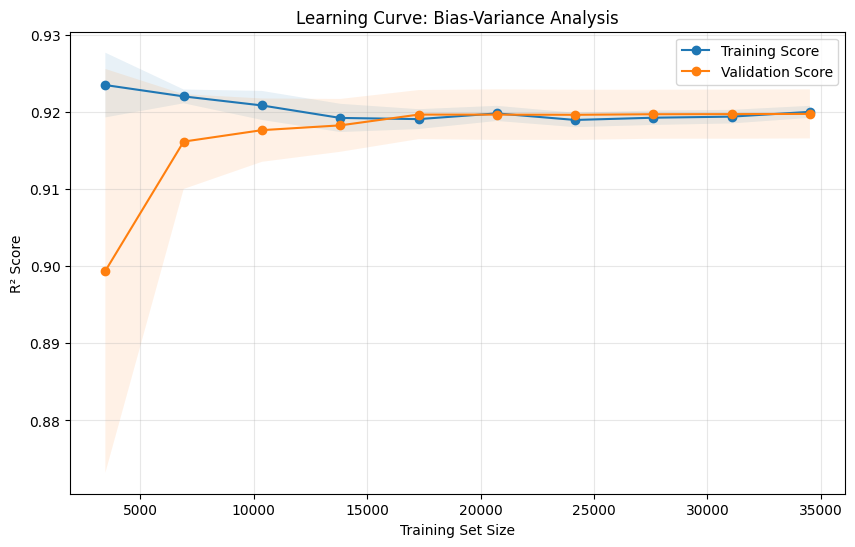

In [123]:
# Demonstrate learning curve
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    LinearRegression(),
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='r2',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.plot(train_sizes, val_mean, label='Validation Score', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('R² Score')
plt.title('Learning Curve: Bias-Variance Analysis')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [124]:
from sklearn.pipeline import Pipeline

# Create production pipeline
production_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train pipeline
production_pipeline.fit(X_train, y_train)

# Predict
y_pred_pipeline = production_pipeline.predict(X_test)

# Evaluate
pipeline_r2 = r2_score(y_test, y_pred_pipeline)
pipeline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pipeline))

print("\n🚀 Production Pipeline Results:")
print(f"R² Score: {pipeline_r2:.4f}")
print(f"RMSE: {pipeline_rmse:.4f}")


🚀 Production Pipeline Results:
R² Score: 0.9189
RMSE: 1135.2116


In [125]:
# Save model for deployment (optional)
import joblib

# Save pipeline
joblib.dump(production_pipeline, 'linear_regression_pipeline.pkl')
print("\n💾 Model saved as 'linear_regression_pipeline.pkl'")

# Load and test
loaded_pipeline = joblib.load('linear_regression_pipeline.pkl')
test_prediction = loaded_pipeline.predict(X_test[:5])

print("\n🧪 Testing Loaded Model:")
print("First 5 predictions:", test_prediction)
print("Actual values:", y_test[:5].values)


💾 Model saved as 'linear_regression_pipeline.pkl'

🧪 Testing Loaded Model:
First 5 predictions: [ 711.88577262 3191.72583727 1947.2464112  2077.29062598 9878.99820896]
Actual values: [ 559 2201 1238 1304 6901]
